In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('..')
from db_config import get_engine

engine = get_engine()

# Read entire table from MySQL
df = pd.read_sql("SELECT * FROM supply_chain", con=engine)

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.isnull().sum())

Shape: (100000, 4)
Columns: ['Drug', 'Demand_Forecast', 'Optimal_Stock_Level', 'Restocking_Strategy']
Drug                   0
Demand_Forecast        0
Optimal_Stock_Level    0
Restocking_Strategy    0
dtype: int64


In [3]:
df['Restocking_Strategy'] = df['Restocking_Strategy'].astype('category')

# Fill nulls
df['Demand_Forecast'].fillna(
    df['Optimal_Stock_Level'], inplace=True)

# Derived columns
df['demand_to_stock_ratio'] = df['Demand_Forecast'] / df['Optimal_Stock_Level'].replace(0, 1)
df['is_understocked']       = df['Optimal_Stock_Level'] < df['Demand_Forecast']
df['shortfall_amount']      = (df['Demand_Forecast'] - df['Optimal_Stock_Level']).clip(lower=0)
df['excess_stock_buffer']   = (df['Optimal_Stock_Level'] - df['Demand_Forecast']).clip(lower=0)
df['annual_restock_freq']   = df['Restocking_Strategy'].map({'Weekly': 52, 'Monthly': 12, 'Quarterly': 4})

print("Cleaned. Understocked products:", df['is_understocked'].sum())

# Save cleaned version back to MySQL
df.to_sql('pharma_supply_clean', con=engine,
          if_exists='replace', index=False)
print("Saved to pharma_supply_clean table")

C:\Users\sssid\AppData\Local\Temp\ipykernel_31308\424335622.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Demand_Forecast'].fillna(


Cleaned. Understocked products: 41851
Saved to pharma_supply_clean table


C:\Users\sssid\AppData\Local\Temp\ipykernel_31308\1237390155.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk = df[df['is_understocked']].groupby('Restocking_Strategy').size().sort_values(ascending=False)


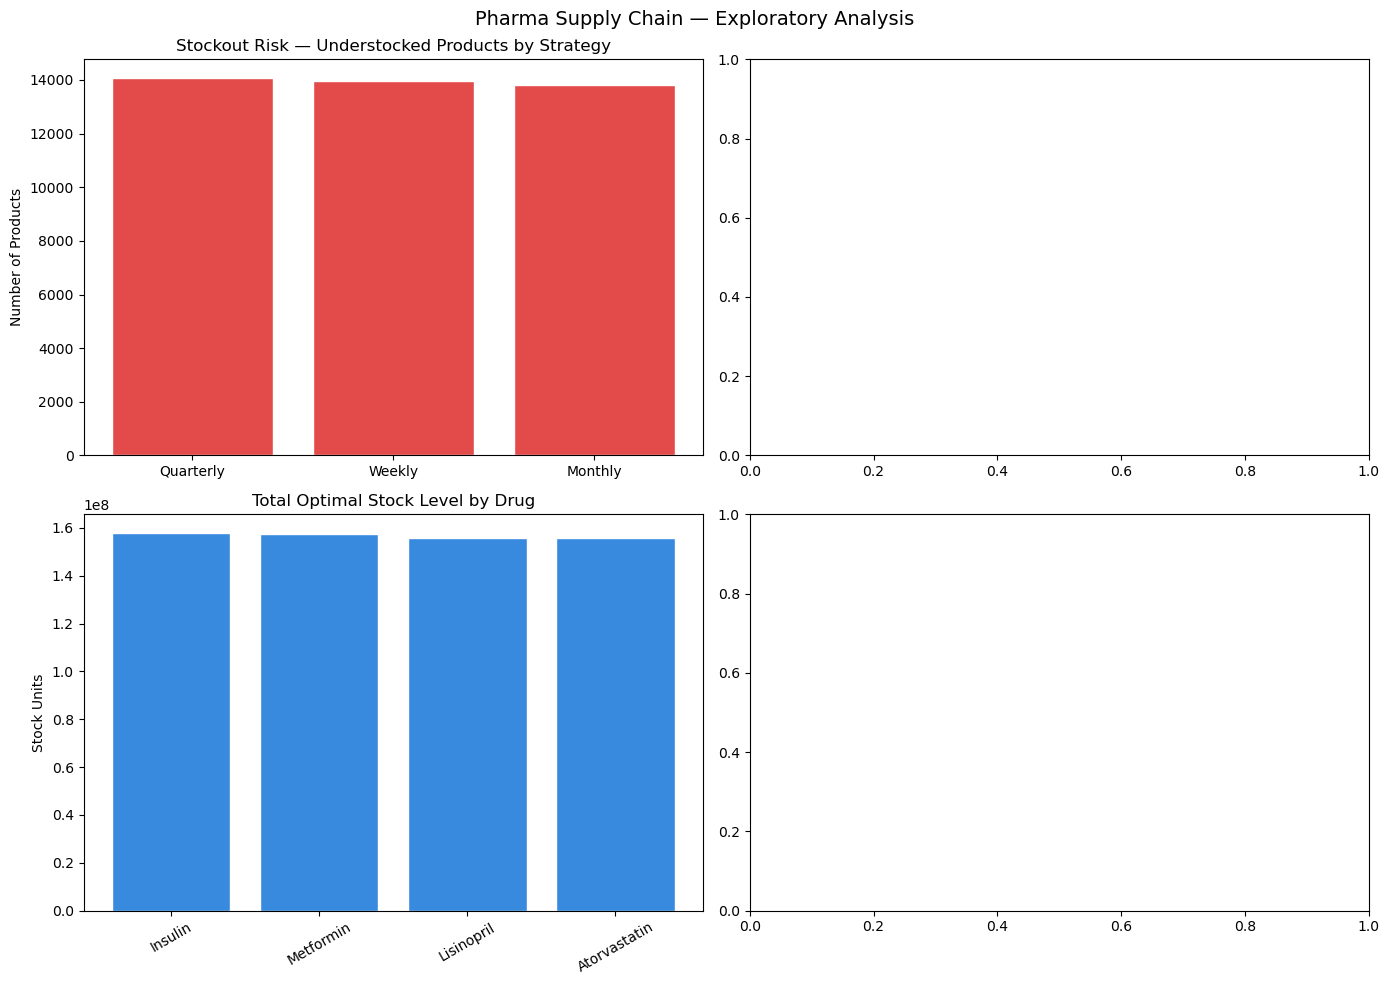

Saved to outputs/eda_analysis.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Pharma Supply Chain — Exploratory Analysis', fontsize=14)

# Chart 1: Understocked products by Restocking Strategy
# Replaces 'region' with 'Restocking_Strategy' and 'is_at_risk' with 'is_understocked'
risk = df[df['is_understocked']].groupby('Restocking_Strategy').size().sort_values(ascending=False)
axes[0,0].bar(risk.index, risk.values, color='#E24B4A', edgecolor='white')
axes[0,0].set_title('Stockout Risk — Understocked Products by Strategy')
axes[0,0].set_ylabel('Number of Products')

# Chart 3: Total Optimal Stock Level by Drug
# Replaces 'category' with 'Drug' and 'inventory_value' with 'Optimal_Stock_Level'
cat_val = df.groupby('Drug')['Optimal_Stock_Level'].sum().sort_values(ascending=False)
axes[1,0].bar(cat_val.index, cat_val.values, color='#378ADD', edgecolor='white')
axes[1,0].set_title('Total Optimal Stock Level by Drug')
axes[1,0].set_ylabel('Stock Units')
axes[1,0].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('../outputs/eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/eda_analysis.png")